### 🤖 Guía de Asistencia con IA: IA como Copiloto de Programación

En esta notebook, utilizaremos la Inteligencia Artificial como copiloto de aprendizaje. Aquí tienes algunas sugerencias de cómo interactuar con un asistente de IA (como Gemini o ChatGPT):

- **Explicación de código**: Si encuentras una función o línea que no comprendes, pregúntale a la IA: *'Explica qué hace esta función línea por línea en Python: [pega tu código]'*.
- **Corrección de errores**: Si tienes un error al ejecutar, copia el error completo y pregúntale: *'¿Por qué este código genera este error y cómo lo soluciono? [pega tu código y error]'*.
- **Optimización**: Pregunta: *'¿Cómo puedo escribir este código de forma más eficiente y limpia?'*.


# Programa Ingenias+ Data Science

## ✏️ Ejercitación: Procesamiento y transformación de datos

Esta notebook les permitiria ejercitar los conceptos de Pandas 🐼  y Procesamiento de datos 📊 que aprendimos hasta ahora. Vamos a seguir trabajando con el dataset que contiene datos relativos a [clientes de un centro comercial](https://www.kaggle.com/akram24/mall-customers) que guardamos en la Notebook 10 luego de eliminar valores faltantes y filtrar outliers.

### 🛠 Procesando datos para ML- Feature Engeneering 🔧

Una vez que visualizamos y exploramos el dataset tenemos una idea de como lucen nuestros datos. Es por eso que ahora debemos empezar a preparar nuestros datos para los siguientes pasos según lo que aprendimos de ellos y las preguntas que nos planteamos.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
datos=pd.read_csv('DataSets/clientes_mall.csv')
print(datos)

     Unnamed: 0  CustomerID   Genre   Age  Annual Income (k$)  \
0             0         1.0    Male  19.0                15.0   
1             1         2.0     NaN  21.0                15.0   
2             2         3.0  Female  20.0                16.0   
3             3         4.0  Female  23.0                16.0   
4             4         5.0     NaN  31.0                17.0   
..          ...         ...     ...   ...                 ...   
195         195       196.0     NaN  35.0               120.0   
196         196       197.0  Female  45.0               126.0   
197         197       198.0    Male  32.0               126.0   
198         198       199.0    Male  32.0               137.0   
199         199       200.0    Male  30.0               137.0   

     Spending Score (1-100)  
0                      39.0  
1                      81.0  
2                       6.0  
3                      77.0  
4                      40.0  
..                      ...  
195      

#### DESCUBRIENDO NUEVAS VARIABLES

🤔 &nbsp; **_¿Puedo generar nuevas variables a través de las ya presentes? ¿Qué aportaría al entendimiento de los datos la creación de esta/s variable/s?_**

Respuesta: Aportaría que las columnas renombradas sean más clara para el posterior análisis de datos

In [6]:
datos.rename(columns={'Spending Score (1-100)':'Spending_Score', 'Annual Income (k$)':'Annual_Income'}, inplace=True)
datos

,Unnamed: 0,CustomerID,Genre,Age,Annual_Income,Spending_Score
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0
...,...,...,...,...,...,...
195,195,196.0,NaN,35.0,120.0,79.0
196,196,197.0,Female,45.0,126.0,28.0
197,197,198.0,Male,32.0,126.0,74.0
198,198,199.0,Male,32.0,137.0,18.0


#### ESTANDARIZACION DE DATOS

🤔 &nbsp; **_¿Crees que tus variables deben ser estandarizadas?_**

Si es así, elige una estrategia y aplicala

🚀 _Recuerda qué_ vimos dos metodos para estandarizar o reescalar variables: `StandardScaler` que usa z-score y `MinMaxScaler` que reescala los datos linealmente. Lee la documentación para [Standard Scaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) y para [Min Max](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html).

- En una situación en la vida real, este paso podríamos realizarlo ahora, ya que ya sabriamos que algoritmo queremos usar o pregunta nos queremos contenstar. En el contexto del curso, en la clase 6 aún no hemos visto aprendizaje automatico. Por lo cual, si no consideraron realizar un scaling esta bien. Podrán hacerlo en el ejercicio de la clase 8, que utilizaremos este dataset.

In [7]:
from sklearn.preprocessing import StandardScaler

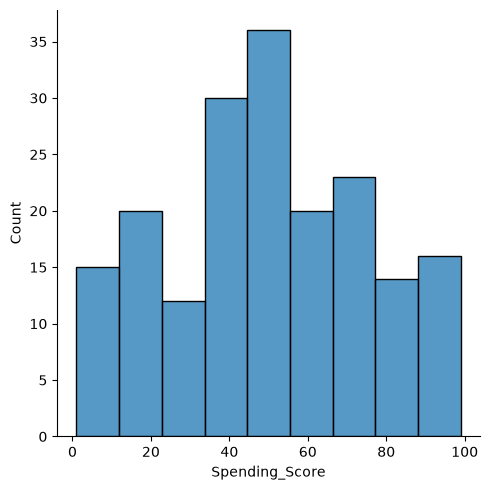

In [8]:
sns.displot(datos['Spending_Score'])


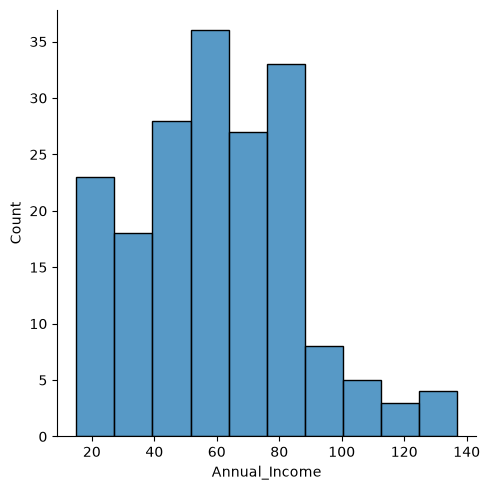

In [9]:
sns.displot(datos['Annual_Income'])

In [10]:
scaler = StandardScaler()

In [11]:
income_scale = scaler.fit_transform(datos[['Annual_Income']]) #estandarización

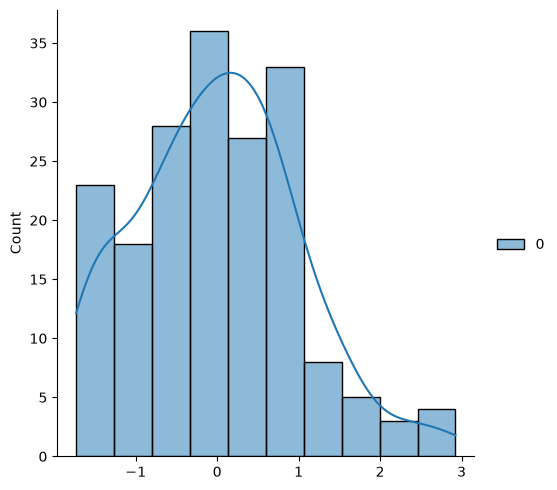

In [12]:
sns.displot(income_scale, kde=True)


#### TRANSFORMACION DE VARIABLES

🤔 &nbsp; **¿Tienes variables categoricas en tu dataset? ¿Estan representadas por números o por strings? ¿Crees que debes generar variables dummies o realizar un encoding de las categorias?**

🚀 _Recuerda qué_ hablamos de varias funciones para poder llevar a cabo estas transformaciones. Algunas de ellas como `get_dummies` y `map` pertenecen a `pandas`, mientras que otras como `LabelEncoder` y `OneHotEncoder` son parte de `sklearn`.

Si queres saber más, chequea la documentación de [get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html), [map](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.map.html), [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) y [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

Respuesta: si, tengo la variable género que tiene dos categorías (female y male), están representadas por strings.

In [13]:
pd.get_dummies(datos, columns=["Genre"])

,Unnamed: 0,CustomerID,Age,Annual_Income,Spending_Score,Genre_Female,Genre_Male
0,0,1.0,19.0,15.0,39.0,False,True
1,1,2.0,21.0,15.0,81.0,False,False
2,2,3.0,20.0,16.0,6.0,True,False
3,3,4.0,23.0,16.0,77.0,True,False
4,4,5.0,31.0,17.0,40.0,False,False
...,...,...,...,...,...,...,...
195,195,196.0,35.0,120.0,79.0,False,False
196,196,197.0,45.0,126.0,28.0,True,False
197,197,198.0,32.0,126.0,74.0,False,True
198,198,199.0,32.0,137.0,18.0,False,True


In [14]:
pd.get_dummies(datos["Genre"])

,Female,Male
0,False,True
1,False,False
2,True,False
3,True,False
4,False,False
...,...,...
195,False,False
196,True,False
197,False,True
198,False,True


In [15]:
datos[['female', 'male']] = pd.get_dummies(datos["Genre"])

In [16]:
datos.head()

,Unnamed: 0,CustomerID,Genre,Age,Annual_Income,Spending_Score,female,male
0,0,1.0,Male,19.0,15.0,39.0,False,True
1,1,2.0,NaN,21.0,15.0,81.0,False,False
2,2,3.0,Female,20.0,16.0,6.0,True,False
3,3,4.0,Female,23.0,16.0,77.0,True,False
4,4,5.0,NaN,31.0,17.0,40.0,False,False


#### 💾 &nbsp; GUARDANDO EL ARCHIVO PARA LOS SIGUIENTES PASOS

1) **Utiliza la función `.to_csv()` para guardar tu dataset**.

In [17]:
datos = datos.to_csv('datos_procesados.csv', index=False)